In [1]:
import pandas as pd 
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

# 네트워크 정보

In [2]:
unit_mob = 200

In [4]:
nodelist = pd.read_csv("data/nodelist_connected.csv")
edgelist = pd.read_csv("data/edgelist_symmetric.csv")

edgelist["mobility"] = edgelist["Max. Number of Routes"] * unit_mob
nodelist = nodelist.set_index("ID")

In [5]:
num_nodes = len(nodelist)
num_edges = len(edgelist)

global_pop = nodelist["Population"].sum()
global_mob = edgelist["mobility"].sum()

# 결과 로드

In [6]:
results = pd.read_csv("results/test_greedy_bc-results.csv")
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160650 entries, 0 to 160649
Data columns (total 15 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   Number of edge cuts                     160650 non-null  int64  
 1   Edge cut seed                           160650 non-null  int64  
 2   Total mobility cut                      160650 non-null  float64
 3   Largest connected component size        160650 non-null  int64  
 4   Maximum connected component population  160650 non-null  float64
 5   Diameter                                160650 non-null  float64
 6   Average distance                        160650 non-null  float64
 7   Basic reproduction number               160650 non-null  float64
 8   Recovery time                           160650 non-null  float64
 9   Global effective reproduciton number    160650 non-null  float64
 10  Infection origin                        1606

In [7]:
np.sum(results["Solver message"] != "A termination event occurred.")

1089

In [8]:
results["Relative largest connected component size"] = results["Largest connected component size"] / num_nodes
results["Maximum connected component population fraction"] = results["Maximum connected component population"] / global_pop

results["Fraction of edge cuts"] = results["Number of edge cuts"] / num_edges
results["Fraction of mobility cuts"] = results["Total mobility cut"] / global_mob

# 시각화

In [9]:
basic_rep = 2.0
r_time = 14.0

sample = results.loc[(results["Basic reproduction number"] == basic_rep) & (results["Recovery time"] == r_time)]

## 네트워크 측정량들

Text(0.5, 1.0, 'Fraction of mobility lost by edge cutting')

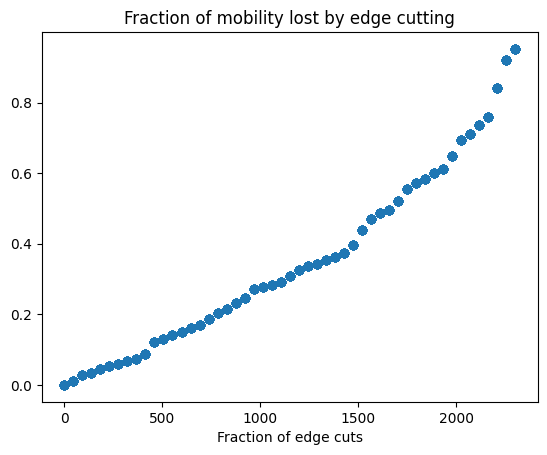

In [10]:
plt.scatter(sample["Number of edge cuts"], sample["Fraction of mobility cuts"], alpha=0.02)

plt.xlabel("Fraction of edge cuts")
plt.title("Fraction of mobility lost by edge cutting")

Text(0.5, 1.0, 'Fraction of nodes in largest connected component')

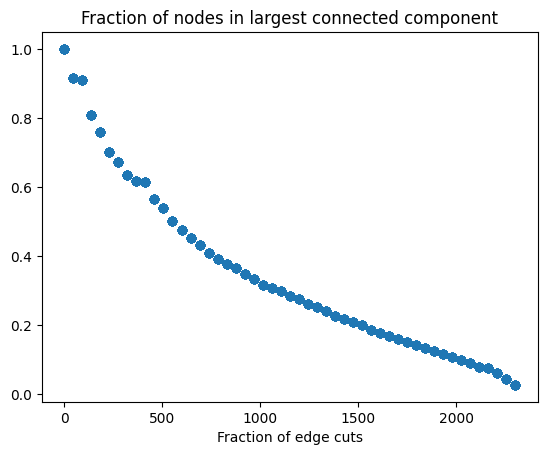

In [11]:
plt.scatter(sample["Number of edge cuts"], sample["Relative largest connected component size"], alpha=0.02)

plt.xlabel("Fraction of edge cuts")
plt.title("Fraction of nodes in largest connected component")

Text(0.5, 1.0, 'Fraction of population in largest connected component')

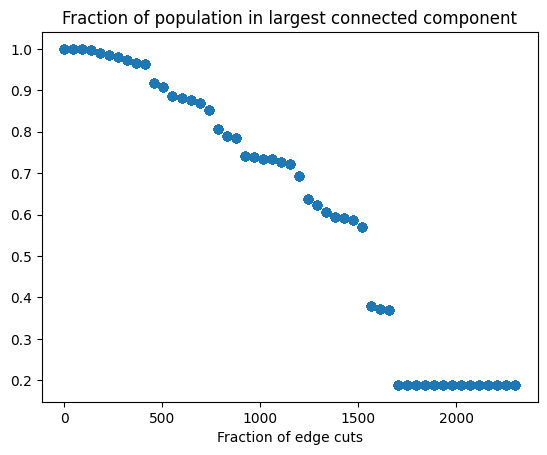

In [12]:
plt.scatter(sample["Number of edge cuts"], sample["Maximum connected component population fraction"], alpha=0.02)

plt.xlabel("Fraction of edge cuts")
plt.title("Fraction of population in largest connected component")

Text(0.5, 1.0, 'Network diameter')

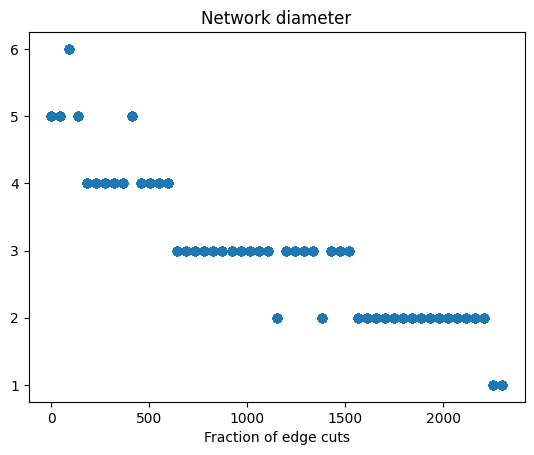

In [13]:
plt.scatter(sample["Number of edge cuts"], sample["Diameter"], alpha=0.02)

plt.xlabel("Fraction of edge cuts")
plt.title("Network diameter")

Text(0.5, 1.0, 'Average distance')

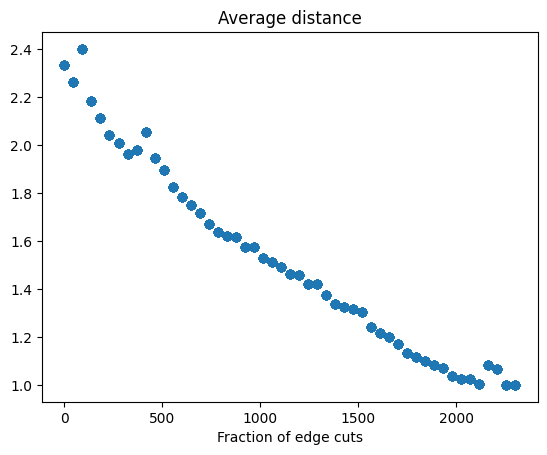

In [14]:
plt.scatter(sample["Number of edge cuts"], sample["Average distance"], alpha=0.02)

plt.xlabel("Fraction of edge cuts")
plt.title("Average distance")

## Global attack rate

Text(0.5, 1.0, 'Global attack rate vs. Fraction of edge cuts')

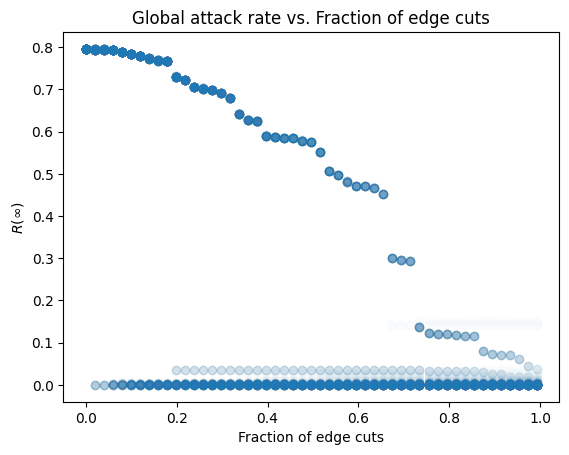

In [15]:
plt.scatter(sample["Fraction of edge cuts"], sample["Global attack rate"], alpha=0.02)

plt.xlabel("Fraction of edge cuts")
plt.ylabel("$R(\infty)$")

plt.title(f"Global attack rate vs. Fraction of edge cuts")

Text(0.5, 1.0, 'Global attack rate vs. Fraction of mobility cuts')

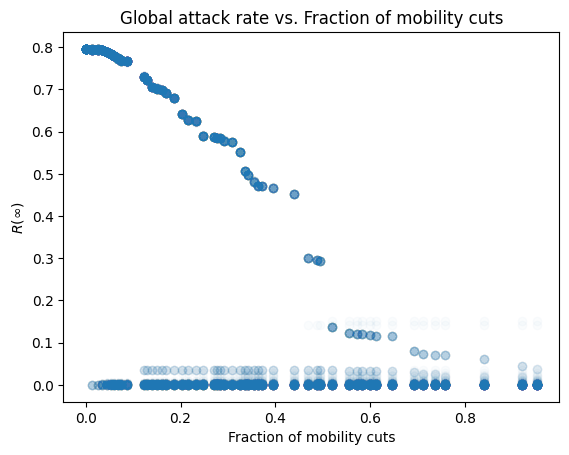

In [16]:
plt.scatter(sample["Fraction of mobility cuts"], sample["Global attack rate"], alpha=0.02)

plt.xlabel("Fraction of mobility cuts")
plt.ylabel("$R(\infty)$")

plt.title(f"Global attack rate vs. Fraction of mobility cuts")

Text(0.5, 1.0, 'Global attack rate vs. Fraction of population in the LCC')

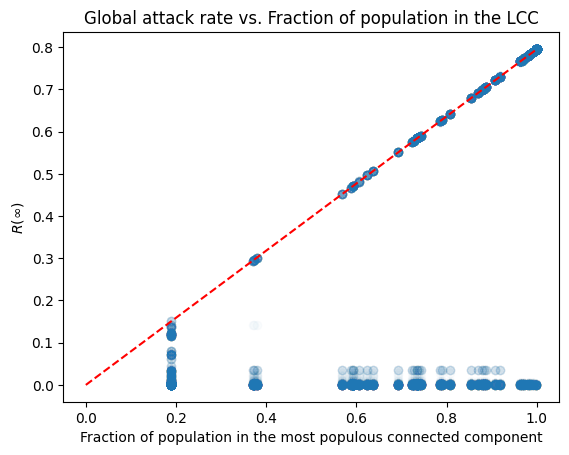

In [17]:
plt.scatter(sample["Maximum connected component population fraction"], sample["Global attack rate"], alpha=0.02)
plt.plot([0, 1.0], [0.0, sample.loc[sample["Number of edge cuts"] == 0, "Global attack rate"].mean()], color='red', linestyle='--')

plt.xlabel("Fraction of population in the most populous connected component")
plt.ylabel("$R(\infty)$")

plt.title(f"Global attack rate vs. Fraction of population in the LCC")

Text(0.5, 1.0, 'Global attack rate vs. Fraction of population in the LCC')

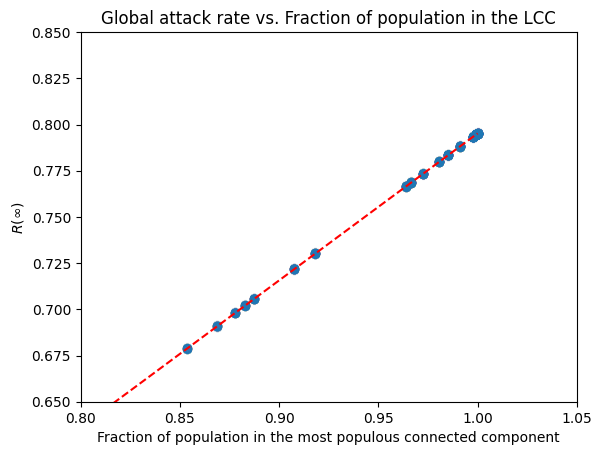

In [18]:
plt.scatter(sample["Maximum connected component population fraction"], sample["Global attack rate"], alpha=0.02)
plt.plot([0, 1.0], [0.0, sample.loc[sample["Number of edge cuts"] == 0, "Global attack rate"].mean()], color='red', linestyle='--')

plt.xlim([0.8, 1.05])
plt.ylim([0.65, 0.85])

plt.xlabel("Fraction of population in the most populous connected component")
plt.ylabel("$R(\infty)$")

plt.title(f"Global attack rate vs. Fraction of population in the LCC")

## Peak time

Text(0.5, 1.0, 'Peak time vs. Fraction of edge cuts')

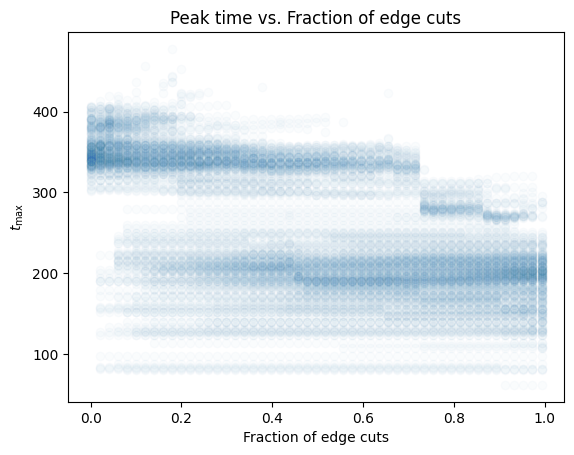

In [19]:
plt.scatter(sample["Fraction of edge cuts"], sample["Peak time"], alpha=0.02)

plt.xlabel("Fraction of edge cuts")
plt.ylabel("$t_\\text{max}$")

plt.title(f"Peak time vs. Fraction of edge cuts")

Text(0.5, 1.0, 'Peak time vs. Fraction of mobility cuts')

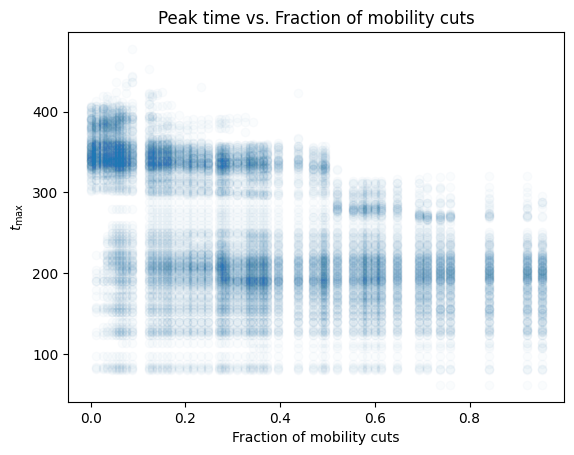

In [20]:
plt.scatter(sample["Fraction of mobility cuts"], sample["Peak time"], alpha=0.02)

plt.xlabel("Fraction of mobility cuts")
plt.ylabel("$t_\\text{max}$")

plt.title(f"Peak time vs. Fraction of mobility cuts")

Text(0.5, 1.0, 'Peak time vs. Diameter')

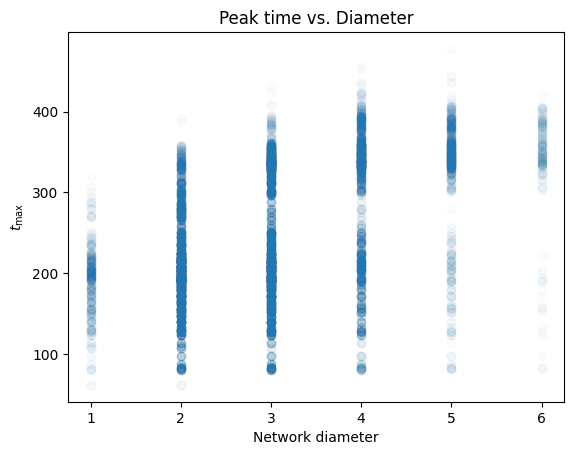

In [21]:
plt.scatter(sample["Diameter"], sample["Peak time"], alpha=0.02)

plt.xlabel("Network diameter")
plt.ylabel("$t_\\text{max}$")

plt.title(f"Peak time vs. Diameter")

Text(0.5, 1.0, 'Peak time vs. Average distance')

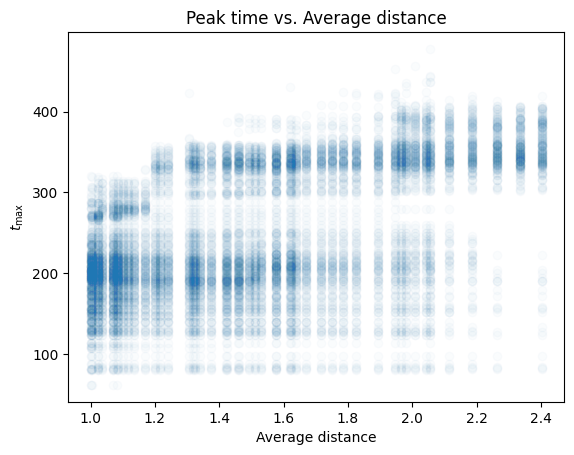

In [22]:
plt.scatter(sample["Average distance"], sample["Peak time"], alpha=0.02)

plt.xlabel("Average distance")
plt.ylabel("$t_\\text{max}$")

plt.title(f"Peak time vs. Average distance")

## Peak severity

Text(0.5, 1.0, 'Peak severity vs. Fraction of edge cuts')

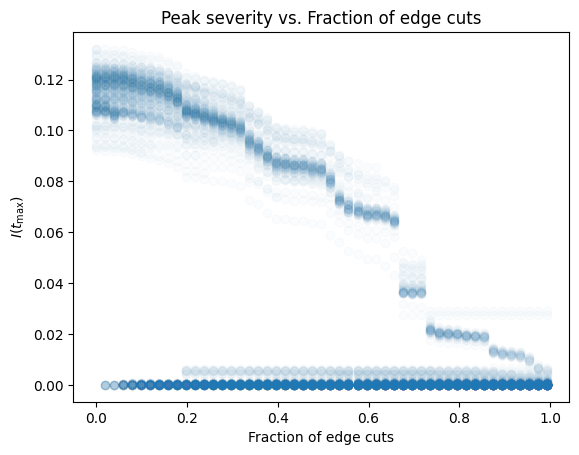

In [23]:
plt.scatter(sample["Fraction of edge cuts"], sample["Peak severity"], alpha=0.02)

plt.xlabel("Fraction of edge cuts")
plt.ylabel("$I(t_\\text{max})$")

plt.title(f"Peak severity vs. Fraction of edge cuts")

Text(0.5, 1.0, 'Peak severity vs. Fraction of mobility cuts')

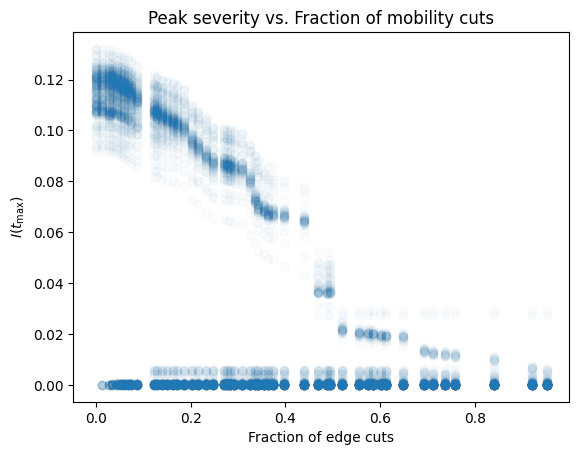

In [24]:
plt.scatter(sample["Fraction of mobility cuts"], sample["Peak severity"], alpha=0.02)

plt.xlabel("Fraction of edge cuts")
plt.ylabel("$I(t_\\text{max})$")

plt.title(f"Peak severity vs. Fraction of mobility cuts")

Text(0.5, 1.0, 'Peak severity vs. Fraction of population in the LCC')

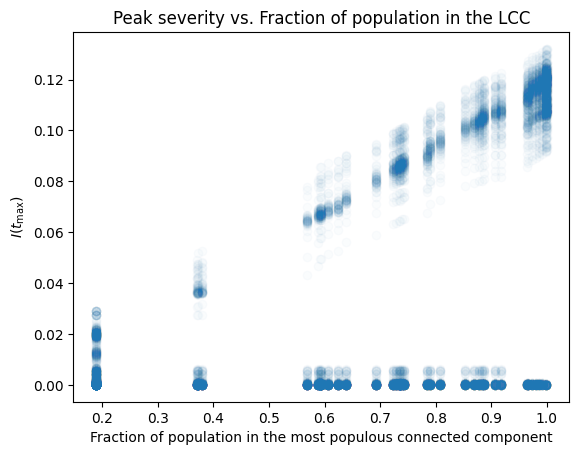

In [25]:
plt.scatter(sample["Maximum connected component population fraction"], sample["Peak severity"], alpha=0.02)

plt.xlabel("Fraction of population in the most populous connected component")
plt.ylabel("$I(t_\\text{max})$")

plt.title(f"Peak severity vs. Fraction of population in the LCC")

Text(0.5, 1.0, 'Peak severity vs. Fraction of population in the LCC')

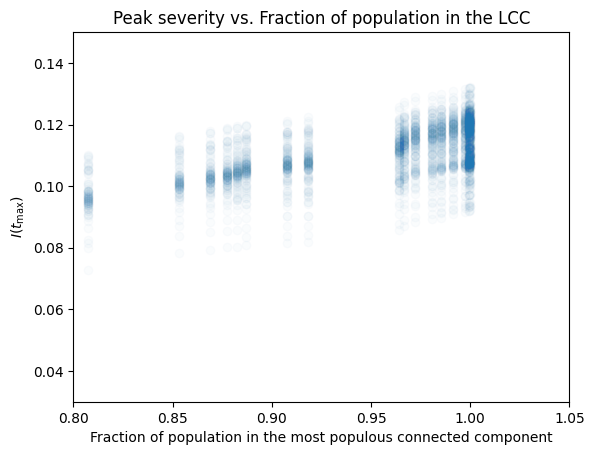

In [26]:
plt.scatter(sample["Maximum connected component population fraction"], sample["Peak severity"], alpha=0.02)

plt.xlim([0.8, 1.05])
plt.ylim([0.03, 0.15])

plt.xlabel("Fraction of population in the most populous connected component")
plt.ylabel("$I(t_\\text{max})$")

plt.title(f"Peak severity vs. Fraction of population in the LCC")

## Global effective reproduction number

Text(0.5, 1.0, 'Effective reproduction number vs. Fraction of edge cuts')

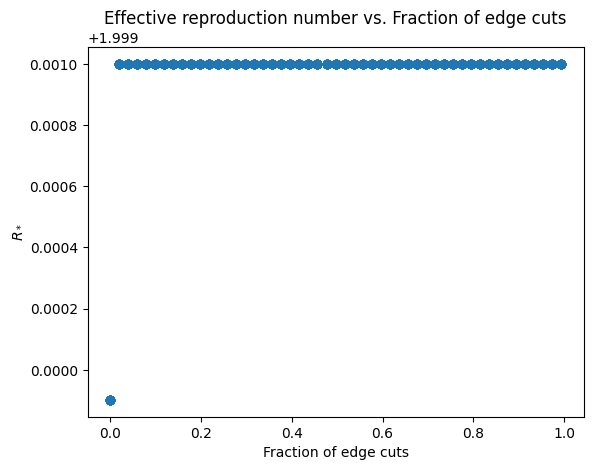

In [27]:
plt.scatter(sample["Fraction of edge cuts"], sample["Global effective reproduciton number"], alpha=0.02)

plt.xlabel("Fraction of edge cuts")
plt.ylabel("$R_*$")

plt.title(f"Effective reproduction number vs. Fraction of edge cuts")

Text(0.5, 1.0, 'Effective reproduction number vs. Fraction of mobility cuts')

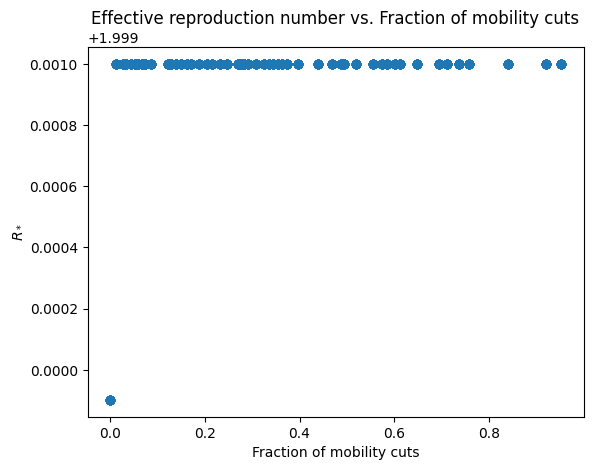

In [28]:
plt.scatter(sample["Fraction of mobility cuts"], sample["Global effective reproduciton number"], alpha=0.02)

plt.xlabel("Fraction of mobility cuts")
plt.ylabel("$R_*$")

plt.title(f"Effective reproduction number vs. Fraction of mobility cuts")